# OpenHealth Price Transparency Analysis

This notebook demonstrates how to access healthcare pricing data using the **OpenHealthDP API** and perform temporal trend analysis to compare costs over time.

### Prerequisites
- Ensure the OpenHealthDP server is running (usually on `http://localhost:3001`)
- Install dependencies: `pip install requests pandas matplotlib seaborn`

In [1]:
%matplotlib inline
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration
BASE_URL = "http://localhost:3001/api/v1/transparency"
API_KEY = "AI4H2-PUBLIC-2023-BETA"  # Default beta key

def fetch_procedure_data(procedure_id, city=None):
    headers = {"x-api-key": API_KEY}
    params = {"procedureId": procedure_id}
    if city:
        params["city"] = city
        
    try:
        response = requests.get(BASE_URL, headers=headers, params=params)
        if response.status_code == 200:
            data = response.json()["data"]
            return pd.DataFrame(data)
        else:
            print(f"API Error {response.status_code}: {response.text}")
            return None
    except Exception as e:
        print(f"Connection Error: {e}")
        return None

## 1. Load Data for MRI Brain (CPT:70551)
Let's fetch pricing data for a common imaging procedure across all providers.

In [2]:
procedure_id = "CPT:70551" # MRI Brain (without contrast)
df = fetch_procedure_data(procedure_id)

if df is not None and not df.empty:
    print(f"Loaded {len(df)} records for {procedure_id}")
    display(df.head())
else:
    print("No data found or error fetching data. Please ensure the server is running.")

Loaded 500 records for CPT:70551


,name,address,city,zip,avg_charge,avg_allowed,procedure_id,source_year
0,Private Specialist (Miskin),55 Fruit St,Boston,02114,74.758897,72.710069,CPT:70551,2022
1,Private Specialist (Miskin),55 Fruit St,Boston,02114,74.758897,72.710069,CPT:70551,2023
2,Private Specialist (Miskin),55 Fruit St,Boston,02114,87.925000,69.844000,CPT:70551,2022
3,Private Specialist (Miskin),55 Fruit St,Boston,02114,87.925000,69.844000,CPT:70551,2023
4,Private Specialist (Lee),55 Lake Ave N,Worcester,01655,125.000000,77.357500,CPT:70551,2019


## 2. Basic Statistical Summary
We can look at the variation between the **Gross Charge** (Sticker Price) and the **Allowed Amount** (Negotiated Rate).

In [3]:
if df is not None and not df.empty:
    stats = df[['avg_charge', 'avg_allowed']].describe()
    display(stats)

,avg_charge,avg_allowed
count,500.000000,500.000000
mean,208.879991,74.811776
std,23.924262,3.194584
min,74.758897,65.458095
25%,196.000000,72.387982
50%,207.451075,74.637361
75%,225.000000,77.007833
max,236.350877,87.290364


## 3. Temporal Trend Analysis with Quantile Intervals
Comparing the temporal trend of **Gross Charges** vs. **Allowed Amounts** over the years. The shaded areas represent the 25th-75th percentile range (interquartile range), showing the price spread among providers.

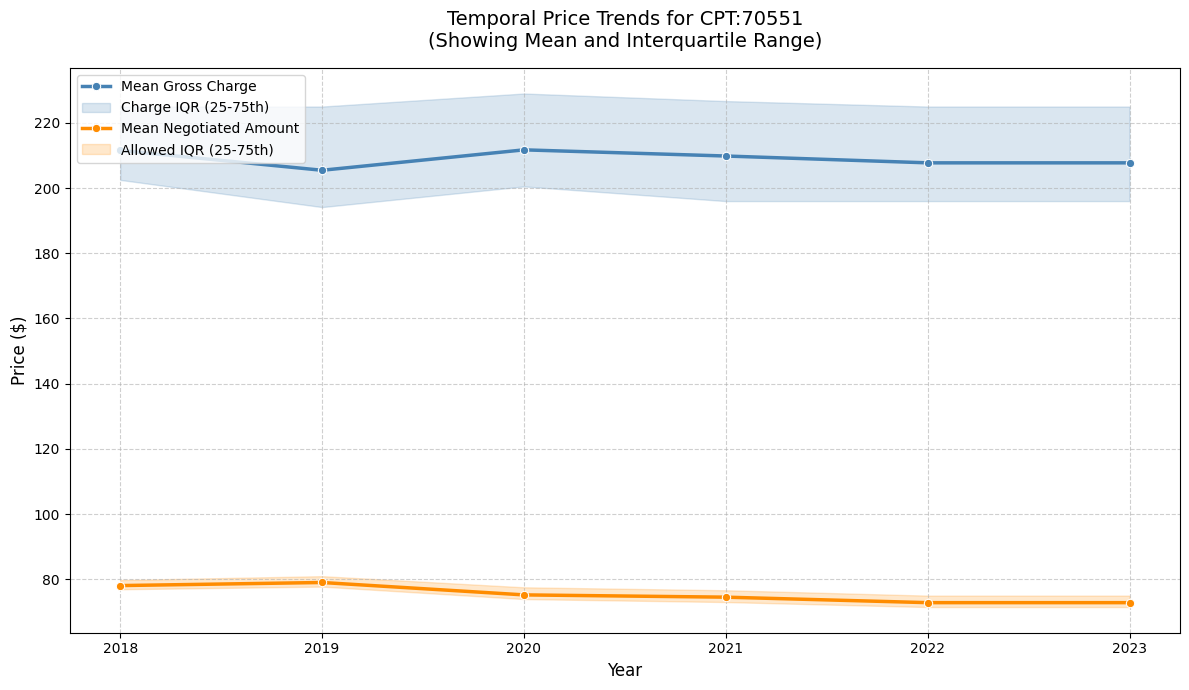

In [4]:
if df is not None and not df.empty and 'source_year' in df.columns:
    # Calculate mean and quantiles by year
    agg_funcs = ['mean', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]
    trend_stats = df.groupby('source_year').agg({
        'avg_charge': agg_funcs,
        'avg_allowed': agg_funcs
    })
    
    # Flatten columns for easier plotting
    trend_stats.columns = [
        'charge_mean', 'charge_q25', 'charge_q75',
        'allowed_mean', 'allowed_q25', 'allowed_q75'
    ]
    trend_stats = trend_stats.reset_index()
    
    plt.figure(figsize=(12, 7))
    
    # Plot Gross Charges (Mean + Shaded Quantile Range)
    sns.lineplot(data=trend_stats, x='source_year', y='charge_mean', marker='o', color='steelblue', label='Mean Gross Charge', linewidth=2.5)
    plt.fill_between(trend_stats['source_year'], trend_stats['charge_q25'], trend_stats['charge_q75'], color='steelblue', alpha=0.2, label='Charge IQR (25-75th)')
    
    # Plot Allowed Amounts (Mean + Shaded Quantile Range)
    sns.lineplot(data=trend_stats, x='source_year', y='allowed_mean', marker='o', color='darkorange', label='Mean Negotiated Amount', linewidth=2.5)
    plt.fill_between(trend_stats['source_year'], trend_stats['allowed_q25'], trend_stats['allowed_q75'], color='darkorange', alpha=0.2, label='Allowed IQR (25-75th)')
    
    plt.title(f'Temporal Price Trends for {procedure_id}\n(Showing Mean and Interquartile Range)', fontsize=14, pad=15)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Price ($)', fontsize=12)
    plt.xticks(trend_stats['source_year'].unique())
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(frameon=True, loc='upper left')
    
    plt.tight_layout()
    plt.show()
else:
    print("source_year column not found or data missing.")